# 03 · V8 Change-point / surprise overlay — discrete events

**Angle:** add discrete *events*, not variance. **BOCPD** run-length P(changepoint), **NIS surprise** off the Kalman we already run, **HMM** filtered regime probability. *Refs: Adams–MacKay 2007 (BOCPD); Kalman NIS consistency; Hamilton 1989 (Markov-switching).*

In [1]:
import sys, os
# Make the notebook self-sufficient: walk up from cwd to the repo root (dir containing `positioning`).
_root = os.getcwd()
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, "positioning")):
    _root = os.path.dirname(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)

import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except Exception:
    def display(x): print(x)

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})
ORANGE="#FF8200"; GREY="#3C3C3C"; BLUE="#1F4E79"; RED="#C00000"; GREEN="#2E7D32"; PURPLE="#7030A0"; TEAL="#0F9D9D"

from positioning.versions import base, compare, richness, dsp, transforms
from positioning.versions import params as P
from positioning.versions.base import responsiveness

def show(df, n=None):
    """Render a DataFrame/dict, truncated."""
    try:
        display(df if n is None else df.head(n))
    except Exception:
        print(df)

def zline(ax, bounded=False):
    """Draw crowd bands for a composite axis."""
    if bounded:
        ax.axhline(80, color=RED, ls="--", lw=0.7); ax.axhline(20, color=GREEN, ls="--", lw=0.7)
    else:
        for k in (1.5, -1.5): ax.axhline(k, color=GREY, ls="--", lw=0.6)
        ax.axhline(0, color=GREY, lw=0.4)

def crossings(z, level=0.0):
    """Count sign changes of (z-level): a proxy for 'deviations per unit time'."""
    s = z.dropna().astype(float) - level
    return int((np.sign(s).diff().abs() > 0).sum())

print("loaded versions package — building shared inputs (cache-first)…")
inp = base.load_inputs()
y10 = inp.y10_w
print(f"inputs: {len(inp.report_dates)} weekly dates {inp.report_dates.min().date()}..{inp.report_dates.max().date()}")

loaded versions package — building shared inputs (cache-first)…


inputs: 422 weekly dates 2018-06-19..2026-07-14


## Build V8 (default) and score it against V0

In [2]:
inp, results = compare.build_all()
r = results["v8"]; c = r.composite.dropna()
print(r.name); print(r.description)
print(f"n finite={len(c)}  latest={(c.iloc[-1] if len(c) else float('nan')):+.4f}  0-crossings={crossings(richness.to_z(c, r.bounded))}")
print("meta keys:", list(r.meta)[:20])

/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


V8 Change-point / surprise overlay
BOCPD P(changepoint) + 1-dof NIS surprise + HMM filtered crowded-regime prob, blended into a signed causal event overlay (discrete events, not added variance).
n finite=397  latest=-0.6848  0-crossings=102
meta keys: ['output', 'source', 'bocpd_hazard', 'bocpd_obs', 'changepoint_prob_latest', 'nis_surprise_latest', 'nis_flag_latest', 'regime_prob_latest', 'blend_latest', 'chi2_threshold_99_1dof', 'hmm_states', 'hmm_converged', 'hmm_regime_means', 'hmm_regime_variances', 'hmm_crowded_idx', 'n_finite', 'note']


In [3]:
# Score the default build vs V0 (strict gate)
s = richness.score(r.composite, inp.y10_w, bounded=r.bounded, baseline=results["v0"].composite, name="v8")
def _flat(d, pre=""):
    for k, v in (d or {}).items():
        if isinstance(v, dict): _flat(v, pre+str(k)+".")
        else: print(f"  {pre+str(k):38s} {v}")
for sec in ("richness","structure","gate"):
    print(f"[{sec}]"); _flat(s.get(sec))

[richness]
  crossings_per_yr.0                     13.360201511335012
  crossings_per_yr.1                     13.09823677581864
  crossings_per_yr.2                     0.0
  turns_per_yr                           27.11335012594458
  n_turns                                207
  bienayme_z                             -6.720864098741304
  n                                      397
  rice_2σ_per_yr                         1.0365599851982232
[structure]
  ou_half_life_wk                        1.5952159401771873
  spectral_entropy                       0.8249573419960298
  n_eff                                  110.09274910281268
[gate]
  pass                                   False
  reasons                                ['incremental IC not positive (-0.259); ok (n_subset=42)', 'added-IC does not beat surrogates (p=0.445 ≥ 0.05, kind=iaaft)', 'CPCV OOS IC not positive (mean=-0.006, n_paths=15)', '|t| below hurdle (-0.47 ≤ 3, n_eff-adjusted)']
  incremental_ic                         -

## V8 vs V0 through time

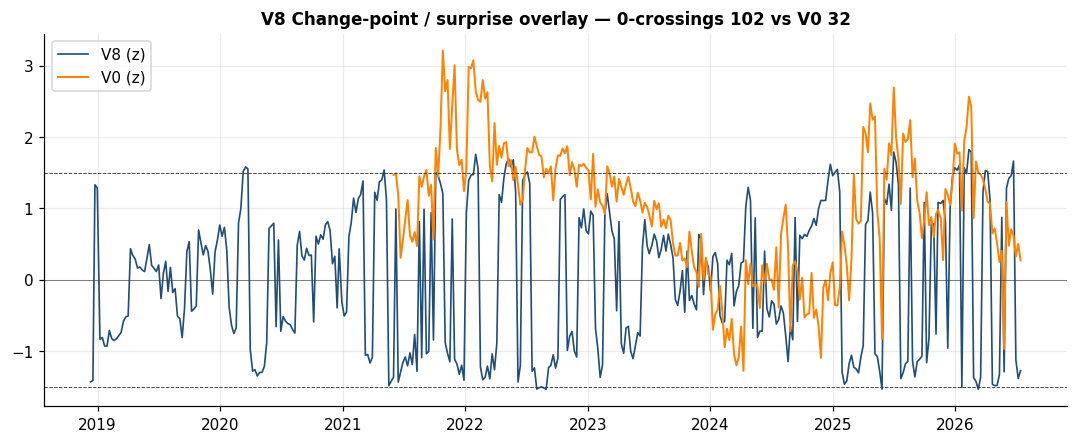

In [4]:
v0 = results["v0"].composite.dropna()
fig, ax = plt.subplots(figsize=(12, 4.4))
ax.plot(c.index, richness.to_z(c, r.bounded), color=BLUE, lw=1.1, label="V8 (z)")
ax.plot(v0.index, richness.to_z(v0, False), color=ORANGE, lw=1.3, label="V0 (z)")
zline(ax); ax.legend(loc="upper left")
ax.set_title(f"{r.name[:48]} — 0-crossings {crossings(richness.to_z(c, r.bounded))} vs V0 {crossings(richness.to_z(v0, False))}")
display(fig); plt.close(fig)

## Variants

/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,cfg,n,latest,meta
0,{},397,-0.684829,"{'output': 'blend', 'source': 'signal', 'bocpd..."
1,{'output': 'changepoint_prob'},422,0.015144,"{'output': 'changepoint_prob', 'source': 'sign..."
2,{'output': 'regime_prob'},422,1.000000,"{'output': 'regime_prob', 'source': 'signal', ..."
3,{'bocpd_obs': 'gaussian'},397,-0.674145,"{'output': 'blend', 'source': 'signal', 'bocpd..."
4,{'hmm_states': 3},397,-0.678419,"{'output': 'blend', 'source': 'signal', 'bocpd..."


/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


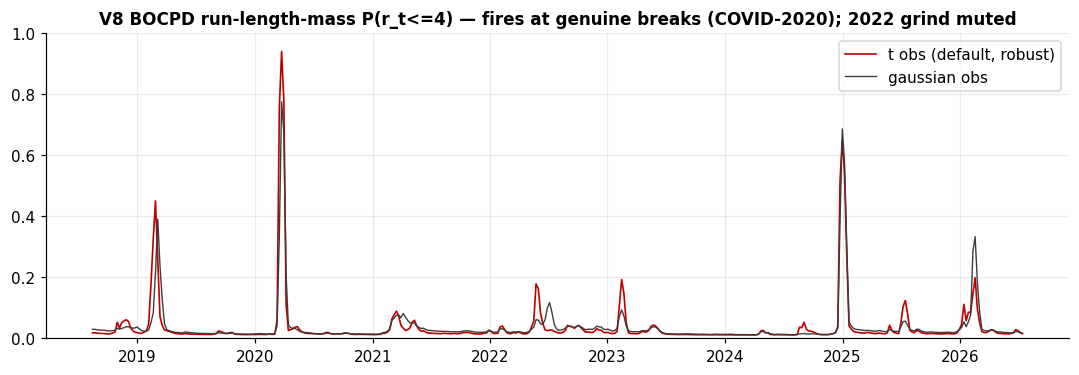

top change-point dates (t obs): ['2024-12-24', '2025-01-07', '2024-12-31', '2020-03-17', '2020-03-31', '2020-03-24']


In [5]:
cfgs = [{}, {"output":"changepoint_prob"}, {"output":"regime_prob"}, {"bocpd_obs":"gaussian"}, {"hmm_states":3}]
rows = []
for cfg in cfgs:
    rr = compare.BUILDERS["v8"](inp, cfg)
    cc = rr.composite.dropna()
    rows.append({"cfg": str(cfg)[:30], "n": len(cc), "latest": (cc.iloc[-1] if len(cc) else np.nan),
                 "meta": {k: round(v,3) if isinstance(v,(int,float)) else str(v)[:24]
                          for k,v in list(rr.meta.items())[:5]}})
show(pd.DataFrame(rows))
# BOCPD change-point signal over time. Readout = recent run-length mass P(r_t<=4), NOT P(r_t=0)
# (which is identically the hazard prior and carries no information). First ~8 weeks are the BOCPD
# warm-up edge (the very first point always looks like a 'change') — skip them. Sanity: 2020 COVID.
cp  = compare.BUILDERS["v8"](inp, {"output":"changepoint_prob"}).composite.dropna().iloc[8:]           # t (default)
cpg = compare.BUILDERS["v8"](inp, {"output":"changepoint_prob","bocpd_obs":"gaussian"}).composite.dropna().iloc[8:]
if len(cp):
    fig, ax = plt.subplots(figsize=(12,3.6))
    ax.plot(cp.index,  cp.values,  color=RED,  lw=1.1, label="t obs (default, robust)")
    ax.plot(cpg.index, cpg.values, color=GREY, lw=0.9, label="gaussian obs")
    ax.set_ylim(0,1); ax.legend(loc="upper right")
    ax.set_title("V8 BOCPD run-length-mass P(r_t<=4) — fires at genuine breaks (COVID-2020); 2022 grind muted")
    display(fig); plt.close(fig)
    print("top change-point dates (t obs):", [str(d.date()) for d in cp.sort_values().index[-6:]])

### Note
These are **event** signals (mostly non-negative intensity), signed by the source's deviation so + = crowded-long event. Sanity: BOCPD should light up around 2020 and 2022.